# Test Case 4 - Two Capacitors

Zwei Ausgänge für denselben Eingang: Spannung an `C1` und Spannung an `C2`.


In [1]:
from CircuitCalculator.Circuit.transfer_function import symbolic_transfer_function, numeric_transfer_function, TransferFunctionOutput
from CircuitCalculator.Circuit.circuit import Circuit
from CircuitCalculator.Circuit.Components import components as cmp
from scipy import signal
from IPython.display import display
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt


## Setup Circuit


In [2]:
V0 = 1
R1, R2 = 10, 20
C1 = 5e-3
C2 = 1e-3
circuit = Circuit(
    components=[
        cmp.dc_voltage_source(id='Uq', V=V0, nodes=('1', '0')),
        cmp.resistor(id='R1', R=R1, nodes=('1', '2')),
        cmp.capacitor(id='C1', C=C1, nodes=('2', '3')),
        cmp.resistor(id='R2', R=R2, nodes=('3', '0')),
        cmp.capacitor(id='C2', C=C2, nodes=('3', '0')),
    ],
    ground_node='0'
)
circuit


Circuit(components=[Component(type='dc_voltage_source', id='Uq', nodes=('1', '0'), value={'V': 1, 'R': 0, 'w': 0, 'phi': 0}), Component(type='resistor', id='R1', nodes=('1', '2'), value={'R': 10}), Component(type='capacitor', id='C1', nodes=('2', '3'), value={'C': 0.005}), Component(type='resistor', id='R2', nodes=('3', '0'), value={'R': 20}), Component(type='capacitor', id='C2', nodes=('3', '0'), value={'C': 0.001})], ground_node='0')

## Configure Transfer Functions


In [3]:
analyses = [
    {
        'title': 'H_Uq->Uc1(s)',
        'input_id': 'Uq',
        'output': TransferFunctionOutput.voltage('C1'),
        'output_label': 'U_C1',
    },
    {
        'title': 'H_Uq->Uc2(s)',
        'input_id': 'Uq',
        'output': TransferFunctionOutput.voltage('C2'),
        'output_label': 'U_C2',
    },
]
analyses


[{'title': 'H_Uq->Uc1(s)',
  'input_id': 'Uq',
  'output': TransferFunctionOutput(kind='voltage', id='C1'),
  'output_label': 'U_C1'},
 {'title': 'H_Uq->Uc2(s)',
  'input_id': 'Uq',
  'output': TransferFunctionOutput(kind='voltage', id='C2'),
  'output_label': 'U_C2'}]

## Calculate Symbolic And Numeric Transfer Functions


In [4]:
results = []
for analysis in analyses:
    tf_symbolic = symbolic_transfer_function(circuit, input_id=analysis["input_id"], output=analysis["output"])
    tf_numeric = numeric_transfer_function(circuit, input_id=analysis["input_id"], output=analysis["output"])
    results.append({**analysis, "symbolic": tf_symbolic, "numeric": tf_numeric})
results


[{'title': 'H_Uq->Uc1(s)',
  'input_id': 'Uq',
  'output': TransferFunctionOutput(kind='voltage', id='C1'),
  'output_label': 'U_C1',
  'symbolic': SymbolicTransferFunction(expr=(222044604925031*s**2/1000000000000000000000000000000000 + s/50 + 1)/(s**2/1000 + 17*s/100 + 1), input_id='Uq', output=TransferFunctionOutput(kind='voltage', id='C1'), s=s),
  'numeric': NumericTransferFunction(numerator_coeffs=array([  20., 1000.]), denominator_coeffs=array([   1.,  170., 1000.]), input_id='Uq', output=TransferFunctionOutput(kind='voltage', id='C1'))},
 {'title': 'H_Uq->Uc2(s)',
  'input_id': 'Uq',
  'output': TransferFunctionOutput(kind='voltage', id='C2'),
  'output_label': 'U_C2',
  'symbolic': SymbolicTransferFunction(expr=(s + 7105427357601/1562500000000000000000000000)/(10*(s**2/1000 + 17*s/100 + 1)), input_id='Uq', output=TransferFunctionOutput(kind='voltage', id='C2'), s=s),
  'numeric': NumericTransferFunction(numerator_coeffs=array([1.00000000e+02, 2.38742359e-12]), denominator_coeff

## Show Formulas


In [5]:
for result in results:
    print(result["title"])
    display(sp.Eq(sp.Symbol(result["title"]), result["symbolic"].expr))
    print("Numerator:", result["symbolic"].numerator())
    print("Denominator:", result["symbolic"].denominator())
    print("Zeros:", result["symbolic"].zeros() if result["symbolic"].zeros() else "keine")
    print("Poles:", result["symbolic"].poles())
    print("Numeric numerator coefficients:", result["numeric"].numerator_coeffs)
    print("Numeric denominator coefficients:", result["numeric"].denominator_coeffs)
    print()


H_Uq->Uc1(s)


Eq(H_Uq->Uc1(s), (222044604925031*s**2/1000000000000000000000000000000000 + s/50 + 1)/(s**2/1000 + 17*s/100 + 1))

Numerator: 222044604925031*s**2 + 20000000000000000000000000000000*s + 1000000000000000000000000000000000
Denominator: 1000000000000000000000000000000*s**2 + 170000000000000000000000000000000*s + 1000000000000000000000000000000000
Zeros: [-10000000000000000000000000000000/222044604925031 - 10000000000000000*sqrt(999999999999997779553950749690)/222044604925031, -10000000000000000000000000000000/222044604925031 + 10000000000000000*sqrt(999999999999997779553950749690)/222044604925031]
Poles: [-85 - 5*sqrt(249), -85 + 5*sqrt(249)]
Numeric numerator coefficients: [  20. 1000.]
Numeric denominator coefficients: [   1.  170. 1000.]

H_Uq->Uc2(s)


Eq(H_Uq->Uc2(s), (s + 7105427357601/1562500000000000000000000000)/(10*(s**2/1000 + 17*s/100 + 1)))

Numerator: 1562500000000000000000000000*s + 7105427357601
Denominator: 15625000000000000000000000*s**2 + 2656250000000000000000000000*s + 15625000000000000000000000000
Zeros: [-7105427357601/1562500000000000000000000000]
Poles: [-85 - 5*sqrt(249), -85 + 5*sqrt(249)]
Numeric numerator coefficients: [1.00000000e+02 2.38742359e-12]
Numeric denominator coefficients: [   1.  170. 1000.]



## Bode Diagram


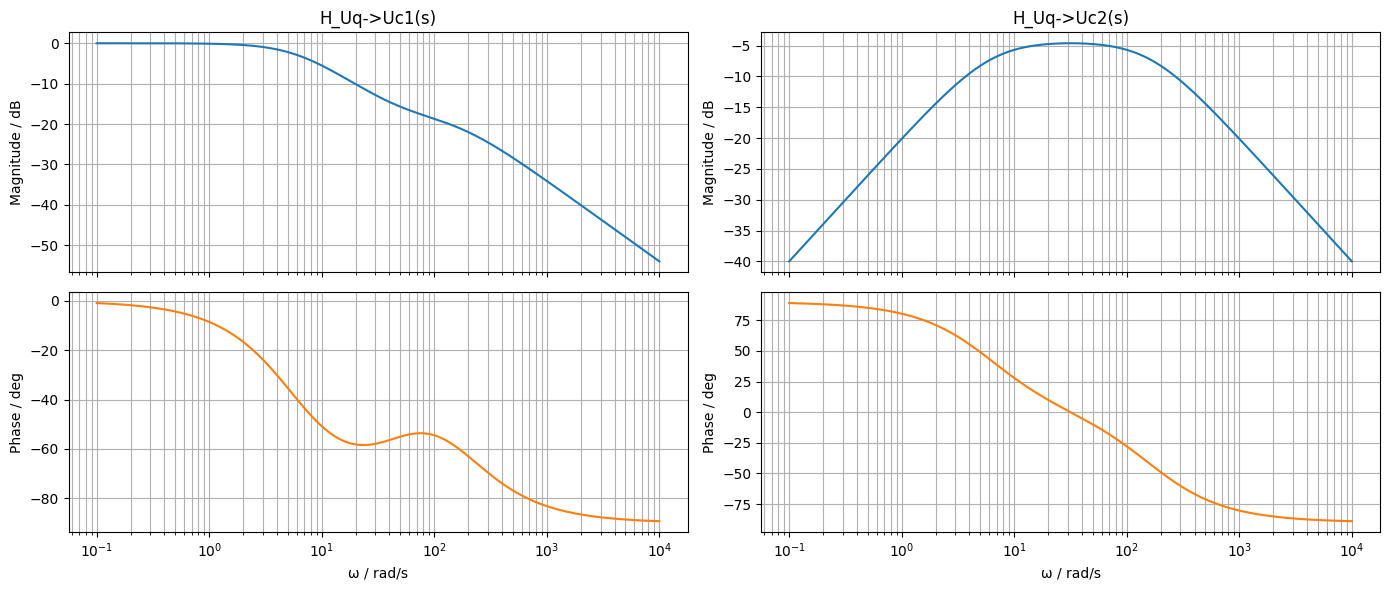

In [6]:
w = np.logspace(-1, 4, 500)
fig, ax = plt.subplots(nrows=2, ncols=len(results), figsize=(7 * len(results), 6), sharex="col")
if len(results) == 1:
    ax = np.array(ax).reshape(2, 1)
for idx, result in enumerate(results):
    system = result["numeric"].transfer_function()
    w_bode, magnitude_db, phase_deg = signal.bode(system, w=w)
    ax[0, idx].semilogx(w_bode, magnitude_db, color="tab:blue")
    ax[0, idx].set_title(result["title"])
    ax[0, idx].set_ylabel("Magnitude / dB")
    ax[0, idx].grid(True, which="both")
    ax[1, idx].semilogx(w_bode, phase_deg, color="tab:orange")
    ax[1, idx].set_xlabel("ω / rad/s")
    ax[1, idx].set_ylabel("Phase / deg")
    ax[1, idx].grid(True, which="both")
plt.tight_layout()
plt.show()


## Ortskurve


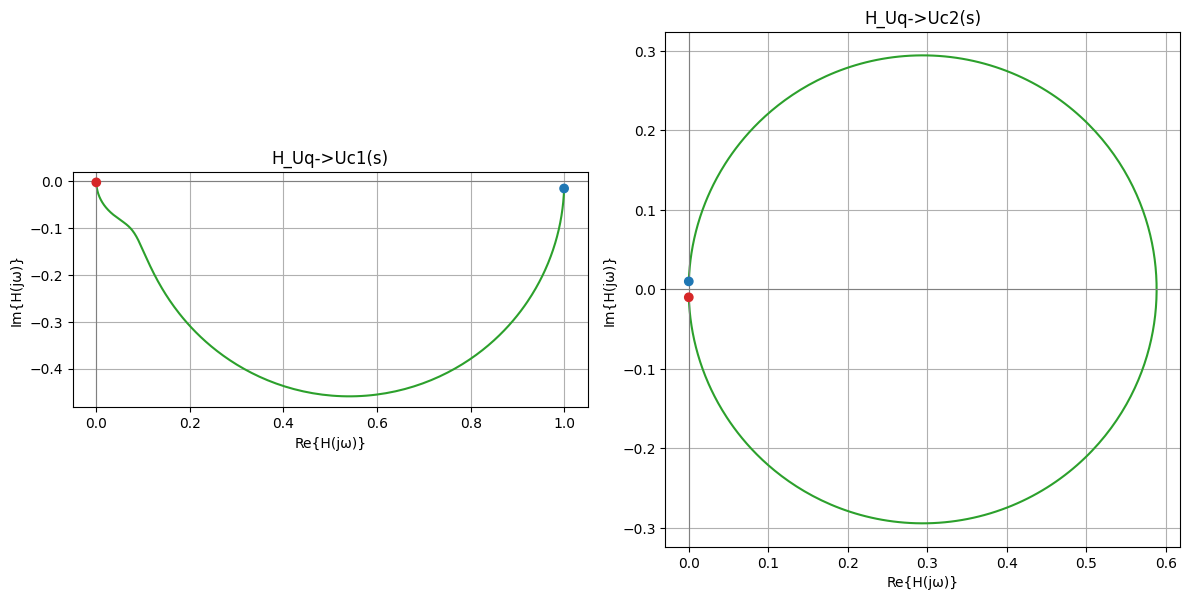

In [7]:
fig, ax = plt.subplots(nrows=1, ncols=len(results), figsize=(6 * len(results), 6))
if len(results) == 1:
    ax = np.array([ax])
for idx, result in enumerate(results):
    system = result["numeric"].transfer_function()
    w_resp, response = signal.freqresp(system, w=w)
    ax[idx].plot(response.real, response.imag, color="tab:green")
    ax[idx].scatter([response.real[0], response.real[-1]], [response.imag[0], response.imag[-1]], color=["tab:blue", "tab:red"], zorder=3)
    ax[idx].axhline(0, color="0.5", linewidth=0.8)
    ax[idx].axvline(0, color="0.5", linewidth=0.8)
    ax[idx].set_xlabel("Re{H(jω)}")
    ax[idx].set_ylabel("Im{H(jω)}")
    ax[idx].set_title(result["title"])
    ax[idx].grid(True)
    ax[idx].set_aspect("equal", "box")
plt.tight_layout()
plt.show()


## Pole-Zero Diagram


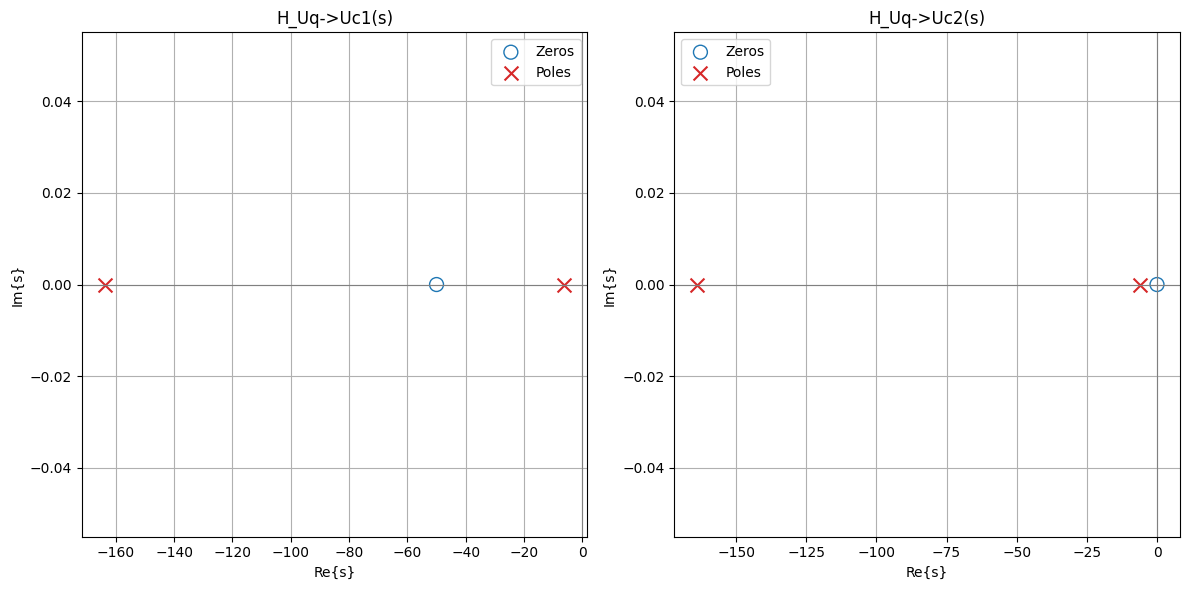

In [8]:
fig, ax = plt.subplots(nrows=1, ncols=len(results), figsize=(6 * len(results), 6))
if len(results) == 1:
    ax = np.array([ax])
for idx, result in enumerate(results):
    zero_values = result["numeric"].zeros()
    pole_values = result["numeric"].poles()
    if zero_values.size > 0:
        ax[idx].scatter(zero_values.real, zero_values.imag, marker="o", s=100, facecolors="none", edgecolors="tab:blue", label="Zeros")
    ax[idx].scatter(pole_values.real, pole_values.imag, marker="x", s=100, color="tab:red", label="Poles")
    ax[idx].axhline(0, color="0.5", linewidth=0.8)
    ax[idx].axvline(0, color="0.5", linewidth=0.8)
    ax[idx].set_xlabel("Re{s}")
    ax[idx].set_ylabel("Im{s}")
    ax[idx].set_title(result["title"])
    ax[idx].grid(True)
    ax[idx].legend()
plt.tight_layout()
plt.show()
